In [2]:
# All imports

import os
import numpy as np
import pandas as pd
import gc 
import seaborn as sns
import matplotlib.pyplot as plt

def show_left_aligned(df):
    display(
        df.style
        .set_properties(**{"text-align": "left"})
        .set_table_styles([
            {"selector": "th", "props": [("text-align", "left")]}
        ])
    )

pd.set_option('display.max_columns', None)
pd.set_option("display.max_colwidth", None)
pd.set_option('display.width', 1000)    

In [3]:

# Read the data and create summary table which will give an overview of the data in each dataset.
data_path = r".\python_project_aiml_logicmojo_dataset"

file_list = os.listdir(data_path)

summary = []

# print(file_list)

for file_name in file_list:
    file_path = os.path.join(data_path,file_name)
    df = pd.read_csv(file_path)
    # #Check for shape of the column 
    # print(f"Shape of file : {i} is {df.shape}")
    # #Check for the column list in each dataset.
    # print(f"Columns of file : {i} is {df.columns.to_list()}")
    # #check for duplicates in each dataset
    # dup_rec_count = df.duplicated().sum()
    # if dup_rec_count > 0:
    #     print(f"Shape of duplicate records for file: {i} is {df[df.duplicated(keep=False)].shape}")
    # # There are no duplicate records in any dataset, few records which shows that there are duplicate records in location.csv, we can ignore that as same zip code can be attched to muiple lat and lag values.
    # # Check for missing values 
    # for c in df.columns.to_list():
    #     miss_value = df[c].isna().sum()
    #     if miss_value > 0 :
    #         print(f"Number of missing valeues for file {i} of column {c} is {miss_value}")

    summary.append({
        "file_name": file_name,
        "n_rows": df.shape[0],
        "n_columns": df.shape[1],
        "columns": ", ".join(df.columns.tolist()),
        "duplicate_full_rows": df.duplicated().sum(),
        "n_missing_vals": df.isna().sum()[df.isna().sum() > 0].to_dict()
    })

summary_df = pd.DataFrame(summary)

show_left_aligned(summary_df)


,file_name,n_rows,n_columns,columns,duplicate_full_rows,n_missing_vals
0,category_translation.csv,71,2,"product_category_name, product_category_name_english",0,{}
1,customers.csv,99441,5,"customer_id, customer_unique_id, customer_zip_code_prefix, customer_city, customer_state",0,{}
2,location.csv,1000163,5,"geolocation_zip_code_prefix, geolocation_lat, geolocation_lng, geolocation_city, geolocation_state",261831,{}
3,orders.csv,99441,8,"order_id, customer_id, order_status, order_purchase_timestamp, order_approved_at, order_delivered_carrier_date, order_delivered_customer_date, order_estimated_delivery_date",0,"{'order_approved_at': 160, 'order_delivered_carrier_date': 1783, 'order_delivered_customer_date': 2965}"
4,order_item.csv,112650,7,"order_id, order_item_id, product_id, seller_id, shipping_limit_date, price, freight_value",0,{}
5,payments.csv,103886,5,"order_id, payment_sequential, payment_type, payment_installments, payment_value",0,{}
6,products.csv,32951,9,"product_id, product_category_name, product_name_lenght, product_description_lenght, product_photos_qty, product_weight_g, product_length_cm, product_height_cm, product_width_cm",0,"{'product_category_name': 610, 'product_name_lenght': 610, 'product_description_lenght': 610, 'product_photos_qty': 610, 'product_weight_g': 2, 'product_length_cm': 2, 'product_height_cm': 2, 'product_width_cm': 2}"
7,reviews.csv,99224,7,"review_id, order_id, review_score, review_comment_title, review_comment_message, review_creation_date, review_answer_timestamp",0,"{'review_comment_title': 87656, 'review_comment_message': 58247}"
8,sellers.csv,3095,4,"seller_id, seller_zip_code_prefix, seller_city, seller_state",0,{}


# Load data to dataframes

In [4]:
# Load data to dataframes
customer_df = pd.read_csv(os.path.join(data_path, "customers.csv"))

orders_df = pd.read_csv(os.path.join(data_path, "orders.csv"))

order_item_df = pd.read_csv(os.path.join(data_path, "order_item.csv"))

products_df = pd.read_csv(os.path.join(data_path, "products.csv"))

cat_trans_df = pd.read_csv(os.path.join(data_path, "category_translation.csv"))

location_df = pd.read_csv(os.path.join(data_path, "location.csv"))

payments_df = pd.read_csv(os.path.join(data_path, "payments.csv"))

reviews_df = pd.read_csv(os.path.join(data_path,"reviews.csv"))

sellers_df = pd.read_csv(os.path.join(data_path, "sellers.csv"))


# Initial analysis on Customer data set

In [5]:
# Finding relationship between customer_unique_id and customer_id
customer_df.groupby("customer_unique_id")["customer_id"].nunique().reset_index(name="customer_id_count").loc[lambda df: df["customer_id_count"] > 1]

,customer_unique_id,customer_id_count
33,00172711b30d52eea8b313a7f2cced02,2
106,004288347e5e88a27ded2bb23747066c,2
124,004b45ec5c64187465168251cd1c9c2f,2
144,0058f300f57d7b93c477a131a59b36c3,2
249,00a39521eb40f7012db50455bf083460,2
...,...,...
95784,ff36be26206fffe1eb37afd54c70e18b,3
95810,ff44401d0d8f5b9c54a47374eb48c1b8,2
95916,ff8892f7c26aa0446da53d01b18df463,2
95934,ff922bdd6bafcdf99cb90d7f39cea5b3,3


# Initial analysis on Orders data set

In [6]:
# In orders tables we have the following columns with the number of null values associated to it 
# 'order_approved_at': 160, 'order_delivered_carrier_date': 1783, 'order_delivered_customer_date': 2965

#Analysis on order_approved_at missing values

print(orders_df[(orders_df["order_approved_at"].isna()) & (orders_df["order_status"] == "delivered")]) # these are the cases where the order_approved_at should not be NaN

print(orders_df.loc[(orders_df["order_approved_at"].isna()) & (orders_df["order_status"] != "delivered"), "order_status"].unique()) # Distinct order status ['canceled' 'created'], that means we can keep NaN for the cancelled orders

print(orders_df[(orders_df["order_approved_at"].isna()) & (orders_df["order_status"] == "created")]) # similarly for created oraders also we can keep the order_approved_at as NaN or we can pust some average date.


                               order_id                       customer_id order_status order_purchase_timestamp order_approved_at order_delivered_carrier_date order_delivered_customer_date order_estimated_delivery_date
5323   e04abd8149ef81b95221e88f6ed9ab6a  2127dc6603ac33544953ef05ec155771    delivered      2017-02-18 14:40:00               NaN          2017-02-23 12:04:47           2017-03-01 13:25:33           2017-03-17 00:00:00
16567  8a9adc69528e1001fc68dd0aaebbb54a  4c1ccc74e00993733742a3c786dc3c1f    delivered      2017-02-18 12:45:31               NaN          2017-02-23 09:01:52           2017-03-02 10:05:06           2017-03-21 00:00:00
19031  7013bcfc1c97fe719a7b5e05e61c12db  2941af76d38100e0f8740a374f1a5dc3    delivered      2017-02-18 13:29:47               NaN          2017-02-22 16:25:25           2017-03-01 08:07:38           2017-03-17 00:00:00
22663  5cf925b116421afa85ee25e99b4c34fb  29c35fc91fc13fb5073c8f30505d860d    delivered      2017-02-18 16:48:35             

In [7]:
# Analysis on order_delivered_carrier_date missing values
print(orders_df.loc[orders_df["order_approved_at"].isna(), "order_status"].unique())

# For delivered and created orders we can impute some values like average of the days after calculating what is the average number of days between order_approved_at and order_delivered_carrier_date.
# For cacelled orders we can keep the values as NaN as of now.

['canceled' 'delivered' 'created']


In [8]:
#Analysis on column order_delivered_customer_date
print(orders_df.loc[orders_df["order_delivered_customer_date"].isna(), "order_status"].unique())

orders_df.loc[(~orders_df["order_delivered_customer_date"].isna()) & (orders_df["order_status"]=='approved')]
# For delivered and created orders we can impute some values like average of the days after calculating what is the average number of days between order_approved_at and order_delivered_carrier_date.
# For cacelled orders we can keep the values as NaN as of now.
# If order_staus is invoiced,shipped,processing,unavailable,approved  then there are no rows with  order_delivered_customer_date as null.
# If order_staus is canceled there are 6 rows which still have order_delivered_customer_date as not null, but there are 619 rows where order_delivered_customer_date is null and order_status is cancellled, so I think we can drop those 6 rows.
# For those records where we have null values for order_delivered_customer_date and order_status as delivered, we have to impute the values with average days between order_delivered_carrier_date and order_delivered_customer_date


['invoiced' 'shipped' 'processing' 'unavailable' 'canceled' 'delivered'
 'created' 'approved']


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date


# Lets join the Customer and order table.

In [9]:
customer_orders_df = orders_df.merge(customer_df, how = "inner", on = "customer_id")
customer_orders_df

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,af07308b275d755c9edb36a90c618231,47813,barreiras,BA
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00,7c142cf63193a1473d2e66489a9ae977,59296,sao goncalo do amarante,RN
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00,72632f0f9dd73dfee390c9b22eb56dd6,9195,santo andre,SP
...,...,...,...,...,...,...,...,...,...,...,...,...
99436,9c5dedf39a927c1b2549525ed64a053c,39bd1228ee8140590ac3aca26f2dfe00,delivered,2017-03-09 09:54:05,2017-03-09 09:54:05,2017-03-10 11:18:03,2017-03-17 15:08:01,2017-03-28 00:00:00,6359f309b166b0196dbf7ad2ac62bb5a,12209,sao jose dos campos,SP
99437,63943bddc261676b46f01ca7ac2f7bd8,1fca14ff2861355f6e5f14306ff977a7,delivered,2018-02-06 12:58:58,2018-02-06 13:10:37,2018-02-07 23:22:42,2018-02-28 17:37:56,2018-03-02 00:00:00,da62f9e57a76d978d02ab5362c509660,11722,praia grande,SP
99438,83c1379a015df1e13d02aae0204711ab,1aa71eb042121263aafbe80c1b562c9c,delivered,2017-08-27 14:46:43,2017-08-27 15:04:16,2017-08-28 20:52:26,2017-09-21 11:24:17,2017-09-27 00:00:00,737520a9aad80b3fbbdad19b66b37b30,45920,nova vicosa,BA
99439,11c177c8e97725db2631073c19f07b62,b331b74b18dc79bcdf6532d51e1637c1,delivered,2018-01-08 21:28:27,2018-01-08 21:36:21,2018-01-12 15:35:03,2018-01-25 23:32:54,2018-02-15 00:00:00,5097a5312c8b157bb7be58ae360ef43c,28685,japuiba,RJ


# Add Ordered Items and seller details with customer_orders_df

In [10]:
sellers_df.columns

Index(['seller_id', 'seller_zip_code_prefix', 'seller_city', 'seller_state'], dtype='object')

In [11]:
customer_orders_seller_item_df = (customer_orders_df.merge(order_item_df, how = "inner", on = "order_id")
                                  .merge(sellers_df, how= "inner", on = "seller_id" ))

customer_orders_seller_item_df


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,seller_zip_code_prefix,seller_city,seller_state
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,1,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72,9350,maua,SP
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,af07308b275d755c9edb36a90c618231,47813,barreiras,BA,1,595fac2a385ac33a80bd5114aec74eb8,289cdb325fb7e7f891c38608bf9e0962,2018-07-30 03:24:27,118.70,22.76,31570,belo horizonte,SP
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO,1,aa4383b373c6aca5d8797843e5594415,4869f7a5dfa277a7dca6462dcf3b52b2,2018-08-13 08:55:23,159.90,19.22,14840,guariba,SP
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00,7c142cf63193a1473d2e66489a9ae977,59296,sao goncalo do amarante,RN,1,d0b61bfb1de832b15ba9d266ca96e5b0,66922902710d126a0e7d26b0e3805106,2017-11-23 19:45:59,45.00,27.20,31842,belo horizonte,MG
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00,72632f0f9dd73dfee390c9b22eb56dd6,9195,santo andre,SP,1,65266b2da20d04dbe00c5c2d3bb7859e,2c9e548be18521d1c43cde1c582c6de8,2018-02-19 20:31:37,19.90,8.72,8752,mogi das cruzes,SP
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
112645,63943bddc261676b46f01ca7ac2f7bd8,1fca14ff2861355f6e5f14306ff977a7,delivered,2018-02-06 12:58:58,2018-02-06 13:10:37,2018-02-07 23:22:42,2018-02-28 17:37:56,2018-03-02 00:00:00,da62f9e57a76d978d02ab5362c509660,11722,praia grande,SP,1,f1d4ce8c6dd66c47bbaa8c6781c2a923,1f9ab4708f3056ede07124aad39a2554,2018-02-12 13:10:37,174.90,20.10,17602,tupa,SP
112646,83c1379a015df1e13d02aae0204711ab,1aa71eb042121263aafbe80c1b562c9c,delivered,2017-08-27 14:46:43,2017-08-27 15:04:16,2017-08-28 20:52:26,2017-09-21 11:24:17,2017-09-27 00:00:00,737520a9aad80b3fbbdad19b66b37b30,45920,nova vicosa,BA,1,b80910977a37536adeddd63663f916ad,d50d79cb34e38265a8649c383dcffd48,2017-09-05 15:04:16,205.99,65.02,8290,sao paulo,SP
112647,11c177c8e97725db2631073c19f07b62,b331b74b18dc79bcdf6532d51e1637c1,delivered,2018-01-08 21:28:27,2018-01-08 21:36:21,2018-01-12 15:35:03,2018-01-25 23:32:54,2018-02-15 00:00:00,5097a5312c8b157bb7be58ae360ef43c,28685,japuiba,RJ,1,d1c427060a0f73f6b889a5c7c61f2ac4,a1043bafd471dff536d0c462352beb48,2018-01-12 21:36:21,179.99,40.59,37175,ilicinea,MG
112648,11c177c8e97725db2631073c19f07b62,b331b74b18dc79bcdf6532d51e1637c1,delivered,2018-01-08 21:28:27,2018-01-08 21:36:21,2018-01-12 15:35:03,2018-01-25 23:32:54,2018-02-15 00:00:00,5097a5312c8b157bb7be58ae360ef43c,28685,japuiba,RJ,2,d1c427060a0f73f6b889a5c7c61f2ac4,a1043bafd471dff536d0c462352beb48,2018-01-12 21:36:21,179.99,40.59,37175,ilicinea,MG


# Analyis on products dataset

In [12]:
# print(products_df["product_category_name"].unique())
print(cat_trans_df.loc[cat_trans_df["product_category_name"] == "fashion_bolsas_e_acessorios"])



          product_category_name product_category_name_english
17  fashion_bolsas_e_acessorios      fashion_bags_accessories


In [13]:
{'product_category_name': 610, 'product_name_lenght': 610, 'product_description_lenght': 610, 'product_photos_qty': 610, 'product_weight_g': 2, 'product_length_cm': 2, 'product_height_cm': 2, 'product_width_cm': 2}

{'product_category_name': 610,
 'product_name_lenght': 610,
 'product_description_lenght': 610,
 'product_photos_qty': 610,
 'product_weight_g': 2,
 'product_length_cm': 2,
 'product_height_cm': 2,
 'product_width_cm': 2}

In [14]:
products_df.loc[products_df["product_category_name"].isna(), ["product_category_name", "product_name_lenght", "product_description_lenght", "product_photos_qty"]].drop_duplicates()

,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty
105,NaN,NaN,NaN,NaN


In [15]:
# We will left join with products data set category_translation because for some of the product ids in products table we do not know the product category.
# As we are building the customer centric data sets so we will join the locvation data set with cusrtomer location and we dont want to miss any customer 

final_df = (customer_orders_seller_item_df.merge(products_df, how = "inner", on = "product_id")
            .merge(cat_trans_df, how = "left", on = "product_category_name")
            .merge(payments_df, how = "left", on = "order_id")
            .merge(location_df.loc[:,["geolocation_zip_code_prefix","geolocation_city", "geolocation_state"]].drop_duplicates(), how = "left", left_on=["customer_zip_code_prefix", "customer_city", "customer_state"]
                   , right_on= ["geolocation_zip_code_prefix", "geolocation_city", "geolocation_state"])
            .merge(reviews_df, how = "inner", on = "order_id")       
                   )
final_df 

# del customer_orders_seller_item_df

# gc.collect()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,seller_zip_code_prefix,seller_city,seller_state,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_category_name_english,payment_sequential,payment_type,payment_installments,payment_value,geolocation_zip_code_prefix,geolocation_city,geolocation_state,review_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,1,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72,9350,maua,SP,utilidades_domesticas,40.0,268.0,4.0,500.0,19.0,8.0,13.0,housewares,1.0,credit_card,1.0,18.12,3149.0,sao paulo,SP,a54f0611adc9ed256b57ede6b6eb5114,4,NaN,"Não testei o produto ainda, mas ele veio correto e em boas condições. Apenas a caixa que veio bem amassada e danificada, o que ficará chato, pois se trata de um presente.",2017-10-11 00:00:00,2017-10-12 03:43:48
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,1,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72,9350,maua,SP,utilidades_domesticas,40.0,268.0,4.0,500.0,19.0,8.0,13.0,housewares,3.0,voucher,1.0,2.00,3149.0,sao paulo,SP,a54f0611adc9ed256b57ede6b6eb5114,4,NaN,"Não testei o produto ainda, mas ele veio correto e em boas condições. Apenas a caixa que veio bem amassada e danificada, o que ficará chato, pois se trata de um presente.",2017-10-11 00:00:00,2017-10-12 03:43:48
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,1,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72,9350,maua,SP,utilidades_domesticas,40.0,268.0,4.0,500.0,19.0,8.0,13.0,housewares,2.0,voucher,1.0,18.59,3149.0,sao paulo,SP,a54f0611adc9ed256b57ede6b6eb5114,4,NaN,"Não testei o produto ainda, mas ele veio correto e em boas condições. Apenas a caixa que veio bem amassada e danificada, o que ficará chato, pois se trata de um presente.",2017-10-11 00:00:00,2017-10-12 03:43:48
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,af07308b275d755c9edb36a90c618231,47813,barreiras,BA,1,595fac2a385ac33a80bd5114aec74eb8,289cdb325fb7e7f891c38608bf9e0962,2018-07-30 03:24:27,118.70,22.76,31570,belo horizonte,SP,perfumaria,29.0,178.0,1.0,400.0,19.0,13.0,19.0,perfumery,1.0,boleto,1.0,141.46,47813.0,barreiras,BA,8d5266042046a06655c8db133d120ba5,4,Muito boa a loja,Muito bom o produto.,2018-08-08 00:00:00,2018-08-08 18:37:50
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO,1,aa4383b373c6aca5d8797843e5594415,4869f7a5dfa277a7dca6462dcf3b52b2,2018-08-13 08:55:23,159.90,19.22,14840,guariba,SP,automotivo,46.0,232.0,1.0,420.0,24.0,19.0,21.0,auto,1.0,credit_card,3.0,179.12,75265.0,vianopolis,GO,e73b67b67587f7644d5bd1a52deb1b01,5,NaN,NaN,2018-08-18 00:00:00,2018-08-22 19:

# Analysis on final data.

In [16]:
final_df.describe()

,customer_zip_code_prefix,order_item_id,price,freight_value,seller_zip_code_prefix,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,payment_sequential,payment_installments,payment_value,geolocation_zip_code_prefix,review_score
count,117332.000000,117332.000000,117332.000000,117332.000000,117332.000000,115637.000000,115637.000000,115637.000000,117312.000000,117312.000000,117312.000000,117312.000000,117329.000000,117329.000000,117329.000000,116964.000000,117332.000000
mean,35059.594978,1.194141,120.522417,20.027075,24452.248543,48.767635,785.809352,2.205497,2110.734656,30.254092,16.612461,23.071271,1.094452,2.940151,172.062565,34970.985260,4.031390
std,29849.293854,0.684241,182.942903,15.828114,27583.536615,10.033983,652.375747,1.717772,3785.084700,16.177472,13.452453,11.745779,0.731174,2.775370,265.388194,29835.162344,1.387994
min,1003.000000,1.000000,0.850000,0.000000,1001.000000,5.000000,4.000000,1.000000,0.000000,7.000000,2.000000,6.000000,1.000000,0.000000,0.000000,1003.000000,1.000000
25%,11250.000000,1.000000,39.900000,13.080000,6429.000000,42.000000,346.000000,1.000000,300.000000,18.000000,8.000000,15.000000,1.000000,1.000000,60.750000,11088.000000,4.000000
50%,24240.000000,1.000000,74.900000,16.280000,13660.000000,52.000000,600.000000,1.000000,700.000000,25.000000,13.000000,20.000000,1.000000,2.000000,108.100000,24230.000000,5.000000
75%,58770.000000,1.000000,134.900000,21.180000,28470.000000,57.000000,983.000000,3.000000,1800.000000,38.000000,20.000000,30.000000,1.000000,4.000000,189.060000,58280.000000,5.000000
max,99990.000000,21.000000,6735.000000,409.680000,99730.000000,76.000000,3992.000000,20.000000,40425.000000,105.000000,105.000000,118.000000,29.000000,24.000000,13664.080000,99990.000000,5.000000


In [17]:
print(final_df.info())
null_counts = final_df.isna().sum()
type(null_counts)
print(null_counts[null_counts>0])

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 117332 entries, 0 to 117331
Data columns (total 43 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   order_id                       117332 non-null  object 
 1   customer_id                    117332 non-null  object 
 2   order_status                   117332 non-null  object 
 3   order_purchase_timestamp       117332 non-null  object 
 4   order_approved_at              117317 non-null  object 
 5   order_delivered_carrier_date   116097 non-null  object 
 6   order_delivered_customer_date  114861 non-null  object 
 7   order_estimated_delivery_date  117332 non-null  object 
 8   customer_unique_id             117332 non-null  object 
 9   customer_zip_code_prefix       117332 non-null  int64  
 10  customer_city                  117332 non-null  object 
 11  customer_state                 117332 non-null  object 
 12  order_item_id                 

In [18]:
# Lets update the date columns from onject data type to date datatype 
columns_to_date = ["order_purchase_timestamp","order_approved_at","order_delivered_carrier_date", "order_delivered_customer_date", "order_estimated_delivery_date", "shipping_limit_date", "review_creation_date", "review_answer_timestamp"]

# print(final_df[columns_to_date].head())

# print("***************************************************************")

# print(final_df[columns_to_date].astype('datetime64[ns]').head())

# print("***************************************************************")

# print(final_df[columns_to_date].apply(pd.to_datetime).head())


# final_df[columns_to_date] = final_df[columns_to_date].astype('datetime64[ns]').head()

# final_df["order_purchase_timestamp"] = final_df["order_purchase_timestamp"].apply(pd.to_datetime)

final_df[columns_to_date] = final_df[columns_to_date].apply(
    lambda col: pd.to_datetime(col, errors="coerce")
)


In [19]:
date1 = pd.to_datetime("2017-02-18 14:40:00")
date2 = pd.to_datetime("2017-10-02 11:07:15")

print(round((date2-date1).total_seconds()/ (24 * 3600),2))

225.85


In [20]:
# final_df.loc[~(final_df["order_approved_at"].isna())]
# As all the missing values for order_approved_at are with order_status as delivered so we will compute the average days between order_purchase_timestamp and order_approved_at for order status as delivered.
# Create a new column order_approved_in_days. Impute the values for which the order_approved in days is null with average value.
# Let's create an other colum which is indicate if order has approval fopr it or not.
final_df["order_has_approval"] = final_df["order_approved_at"].notna().astype(int)
final_df["order_approved_in_days"] = ((final_df["order_approved_at"] - final_df["order_purchase_timestamp"]).dt.total_seconds()/(24 * 3600)).round(2)
# # final_df[(final_df["order_approved_in_days"].isna()) & (final_df["order_approved_at"].isna())]
# order_approved_mean = round(final_df.loc[final_df["order_approved_in_days"].notna(), "order_approved_in_days"].mean(),2)
# print(order_approved_mean)
# final_df["order_approved_in_days"] = final_df["order_approved_in_days"].fillna(order_approved_mean)
# print(final_df["order_approved_in_days"].isna().sum())

In [21]:
#lets impute the values for order_delivered_carrier_date
# print(final_df.loc[(final_df["order_delivered_carrier_date"].isna()), "order_status"].unique())

# print(final_df[final_df["order_delivered_carrier_date"].isna()].groupby("order_status")["order_status"].count())

# A better way is 
print(final_df.loc[final_df["order_delivered_carrier_date"].isna(), "order_status"].value_counts())

print(final_df.loc[final_df["order_delivered_carrier_date"].notna(), "order_status"].value_counts())

print(final_df.loc[((final_df["order_delivered_carrier_date"].notna()) & (final_df["order_delivered_customer_date"].notna())), "order_status"].value_counts())

# print(final_df.loc[(final_df["order_delivered_carrier_date"].notna()), "order_status"].unique())

# Lets createte a flag column called order_handed_to_carrier.

final_df["order_handed_to_carrier"] = final_df["order_delivered_carrier_date"].notna().astype(int)

final_df["order_shipped_in_days"] = ((final_df["order_delivered_customer_date"] - final_df["order_delivered_carrier_date"]).dt.total_seconds()/(24 * 3600)).round(2)




order_status
canceled       483
invoiced       370
processing     370
unavailable      7
approved         3
delivered        2
Name: count, dtype: int64
order_status
delivered    114860
shipped        1167
canceled         70
Name: count, dtype: int64
order_status
delivered    114853
canceled          7
Name: count, dtype: int64


In [22]:
final_df.iloc[:, -4:]

,order_has_approval,order_approved_in_days,order_handed_to_carrier,order_shipped_in_days
0,1,0.01,1,6.06
1,1,0.01,1,6.06
2,1,0.01,1,6.06
3,1,1.28,1,12.04
4,1,0.01,1,9.18
...,...,...,...,...
117327,1,0.01,1,20.76
117328,1,0.01,1,23.61
117329,1,0.01,1,13.33
117330,1,0.01,1,13.33


In [23]:
# product_category_name              1695
# product_name_lenght                1695
# product_description_lenght         1695
# product_photos_qty                 1695
# product_weight_g                     20
# product_length_cm                    20
# product_height_cm                    20
# product_width_cm                     20
# product_category_name_english      1720


# product_category_name_english is having missing values, but its depended on product_category_name, because if product_category_name is missing that means product_category_name_english is also missing.

final_df.loc[(final_df["product_category_name"].isna()) & (final_df["product_category_name_english"].isna())]
final_df.loc[(final_df["product_category_name"].notna()) & (final_df["product_category_name_english"].isna())]

final_df.loc[final_df["order_id"] == "1d7542bb5262913fe0516f7943b69a58"]

# order_item_df.loc[order_item_df["order_id"] == "1d7542bb5262913fe0516f7943b69a58"]

# cat_trans_df.loc[cat_trans_df["product_category_name"] == "pc_gamer"]

products_df.loc[products_df["product_id"] == "6727051471a0fc4a0e7737b57bff2549"]

final_df["cat_missing_flag"] = final_df["product_category_name"].notna().astype("int")

final_df["english_cat_missing_flag"] = final_df["product_category_name_english"].notna().astype("int")

final_df.iloc[:, -6:]




,order_has_approval,order_approved_in_days,order_handed_to_carrier,order_shipped_in_days,cat_missing_flag,english_cat_missing_flag
0,1,0.01,1,6.06,1,1
1,1,0.01,1,6.06,1,1
2,1,0.01,1,6.06,1,1
3,1,1.28,1,12.04,1,1
4,1,0.01,1,9.18,1,1
...,...,...,...,...,...,...
117327,1,0.01,1,20.76,1,1
117328,1,0.01,1,23.61,1,1
117329,1,0.01,1,13.33,1,1
117330,1,0.01,1,13.33,1,1


In [24]:
final_df["delivery_days"] = (
    final_df["order_delivered_customer_date"] -
    final_df["order_purchase_timestamp"]
).dt.days

final_df.loc[final_df["delivery_days"].isna(), ["order_status","order_delivered_customer_date"]].drop_duplicates()

,order_status,order_delivered_customer_date
8,invoiced,NaT
50,shipped,NaT
154,processing,NaT
464,canceled,NaT
3539,delivered,NaT
39211,unavailable,NaT
52972,approved,NaT


In [25]:
final_df.iloc[:, -7:]

,order_has_approval,order_approved_in_days,order_handed_to_carrier,order_shipped_in_days,cat_missing_flag,english_cat_missing_flag,delivery_days
0,1,0.01,1,6.06,1,1,8.0
1,1,0.01,1,6.06,1,1,8.0
2,1,0.01,1,6.06,1,1,8.0
3,1,1.28,1,12.04,1,1,13.0
4,1,0.01,1,9.18,1,1,9.0
...,...,...,...,...,...,...,...
117327,1,0.01,1,20.76,1,1,22.0
117328,1,0.01,1,23.61,1,1,24.0
117329,1,0.01,1,13.33,1,1,17.0
117330,1,0.01,1,13.33,1,1,17.0


# Bellow are the columns for which we can do some safe imputations.

In [26]:
final_df["product_name_lenght"] = final_df["product_name_lenght"].fillna(0)
final_df["product_description_lenght"] = final_df["product_description_lenght"].fillna(0)
final_df["product_photos_qty"] = final_df["product_photos_qty"].fillna(0)

final_df["product_weight_g"] = final_df["product_weight_g"].fillna(final_df["product_weight_g"].median())

In [28]:
final_df["payment_type"] = final_df["payment_type"].fillna("Unknown")
final_df["payment_installments"] = final_df["payment_installments"].fillna(1)
final_df["payment_value"] = final_df["payment_value"].fillna(0)
final_df["payment_sequential"] = final_df["payment_sequential"].fillna(0)

In [29]:
final_df["geo_missing_flag"] = (
    final_df["geolocation_zip_code_prefix"].isna()
).astype(int)

final_df["geolocation_zip_code_prefix"] = final_df["geolocation_zip_code_prefix"].fillna(-1)
final_df["geolocation_city"] = final_df["geolocation_city"].fillna("Unknown")
final_df["geolocation_state"] = final_df["geolocation_state"].fillna("Unknown")

In [30]:
final_df["has_review_comment"] = (
    final_df["review_comment_message"].notna()
).astype(int)

final_df["review_comment_title"] = final_df["review_comment_title"].fillna("")
final_df["review_comment_message"] = final_df["review_comment_message"].fillna("")

In [31]:
final_df.to_csv("final_df.csv")

# Goal in this section is to bring the data to the customer level i.e. one row per customer_unique_id

In [33]:
# Create customer centric features and create a new df.

# del customer_vw_df


customer_vw_df = pd.DataFrame()
customer_vw_df["total_aorders"] = final_df.groupby("customer_unique_id")["order_id"].nunique()# Use .nunique() when you want “how many orders per customer”
customer_vw_df["total_aorders"].unique()
customer_vw_df = customer_vw_df.reset_index()

In [34]:
customer_vw_df["cancelled_orders"] = final_df.loc[final_df["order_status"] == "canceled"].groupby("customer_unique_id")["order_id"].nunique()
customer_vw_df["cancelled_orders"] = customer_vw_df["cancelled_orders"].fillna(0).astype(int)
customer_vw_df["cancelled_orders"].unique()


array([0])

In [35]:
customer_vw_df["delivered_orders"] = final_df.loc[final_df["order_status"] == "delivered"].groupby("customer_unique_id")["order_id"].nunique()
customer_vw_df["delivered_orders"] = customer_vw_df["delivered_orders"].fillna(0).astype(int)
customer_vw_df["delivered_orders"].unique()


array([0])

In [36]:
customer_vw_df

,customer_unique_id,total_aorders,cancelled_orders,delivered_orders
0,0000366f3b9a7992bf8c76cfdf3221e2,1,0,0
1,0000b849f77a49e4a4ce2b2a4ca5be3f,1,0,0
2,0000f46a3911fa3c0805444483337064,1,0,0
3,0000f6ccb0745a6a4b88665a16c9f078,1,0,0
4,0004aac84e0df4da2b147fca70cf8255,1,0,0
...,...,...,...,...
94716,fffcf5a5ff07b0908bd4e2dbc735a684,1,0,0
94717,fffea47cd6d3cc0a88bd621562a9d061,1,0,0
94718,ffff371b4d645b6ecea244b27531430a,1,0,0
94719,ffff5962728ec6157033ef9805bacc48,1,0,0


In [37]:

customer_360_df = (
    final_df
    .groupby("customer_unique_id")
    .agg(
        total_orders=("order_id", "nunique"),
        delivered_orders=("order_status", lambda x: (x == "delivered").sum()),
        canceled_orders=("order_status", lambda x: (x == "canceled").sum())
    ).reset_index()
    )

print(customer_360_df[customer_360_df["customer_unique_id"] == "0000366f3b9a7992bf8c76cfdf3221e2"])
print(customer_vw_df[customer_vw_df["customer_unique_id"] == "0000366f3b9a7992bf8c76cfdf3221e2"])

# final_df.loc[final_df["customer_unique_id"] == "0000366f3b9a7992bf8c76cfdf3221e2"]

print(orders_df.loc[orders_df["customer_id"] == "fadbb3709178fc513abc1b2670aa1ad2"])


                 customer_unique_id  total_orders  delivered_orders  canceled_orders
0  0000366f3b9a7992bf8c76cfdf3221e2             1                 1                0
                 customer_unique_id  total_aorders  cancelled_orders  delivered_orders
0  0000366f3b9a7992bf8c76cfdf3221e2              1                 0                 0
                               order_id                       customer_id order_status order_purchase_timestamp    order_approved_at order_delivered_carrier_date order_delivered_customer_date order_estimated_delivery_date
52798  e22acc9c116caa3f2b7121bbb380d08e  fadbb3709178fc513abc1b2670aa1ad2    delivered      2018-05-10 10:56:27  2018-05-10 11:11:18          2018-05-12 08:18:00           2018-05-16 20:48:37           2018-05-21 00:00:00


In [38]:
final_df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,seller_zip_code_prefix,seller_city,seller_state,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_category_name_english,payment_sequential,payment_type,payment_installments,payment_value,geolocation_zip_code_prefix,geolocation_city,geolocation_state,review_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp,order_has_approval,order_approved_in_days,order_handed_to_carrier,order_shipped_in_days,cat_missing_flag,english_cat_missing_flag,delivery_days,geo_missing_flag,has_review_comment
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,1,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72,9350,maua,SP,utilidades_domesticas,40.0,268.0,4.0,500.0,19.0,8.0,13.0,housewares,1.0,credit_card,1.0,18.12,3149.0,sao paulo,SP,a54f0611adc9ed256b57ede6b6eb5114,4,,"Não testei o produto ainda, mas ele veio correto e em boas condições. Apenas a caixa que veio bem amassada e danificada, o que ficará chato, pois se trata de um presente.",2017-10-11,2017-10-12 03:43:48,1,0.01,1,6.06,1,1,8.0,0,1
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,1,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72,9350,maua,SP,utilidades_domesticas,40.0,268.0,4.0,500.0,19.0,8.0,13.0,housewares,3.0,voucher,1.0,2.00,3149.0,sao paulo,SP,a54f0611adc9ed256b57ede6b6eb5114,4,,"Não testei o produto ainda, mas ele veio correto e em boas condições. Apenas a caixa que veio bem amassada e danificada, o que ficará chato, pois se trata de um presente.",2017-10-11,2017-10-12 03:43:48,1,0.01,1,6.06,1,1,8.0,0,1
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,1,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72,9350,maua,SP,utilidades_domesticas,40.0,268.0,4.0,500.0,19.0,8.0,13.0,housewares,2.0,voucher,1.0,18.59,3149.0,sao paulo,SP,a54f0611adc9ed256b57ede6b6eb5114,4,,"Não testei o produto ainda, mas ele veio correto e em boas condições. Apenas a caixa que veio bem amassada e danificada, o que ficará chato, pois se trata de um presente.",2017-10-11,2017-10-12 03:43:48,1,0.01,1,6.06,1,1,8.0,0,1
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,af07308b275d755c9edb36a90c618231,47813,barreiras,BA,1,595fac2a385ac33a80bd5114aec74eb8,289cdb325fb7e7f891c38608bf9e0962,2018-07-30 03:24:27,118.70,22.76,31570,belo horizonte,SP,perfumaria,29.0,178.0,1.0,400.0,19.0,13.0,19.0,perfumery,1.0,boleto,1.0,141.46,47813.0,barreiras,BA,8d5266042046a06655c8db133d120ba5,4,Muito boa a loja,Muito bom o produto.,2018-08-08,2018-08-08 18:37:50,1,1.28,1,12.04,1,1,13.0,0,1
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO,1,aa4383b373c6aca5d8797843e5594415,4869f7a5dfa277a7dca6462dcf3b52b2,2018-08-13 08:55:23,159.90,19.22

Feature Engineering 

In [39]:
# So the issue is we can not just indivisually calculate feartures and add that as a column we will see the missmatch in the data.
# We can solve this by using groupby and agg .

del customer_360_df

customer_360_df = (
    final_df
    .groupby("customer_unique_id")
    .agg(
        total_orders=("order_id", "nunique"),
        delivered_orders=("order_status", lambda x: (x == "delivered").sum()),
        canceled_orders=("order_status", lambda x: (x == "canceled").sum()),
        total_spent = ("payment_value", "sum"),
        avg_order_value = ("payment_value", "mean"),
        avg_approval_days = ("order_approved_in_days", "mean"),
        carrier_rate = ("order_handed_to_carrier", "mean"),
        avg_review_score = ("review_score", "mean"),
        review_rate = ("has_review_comment", "mean"),
        total_order_value = ("price","sum"),
    ).reset_index()
    )

# In the above code the NaN values are already handled like if for a customer the values for "order_approved_in_days" is [1.2, 0.5, NaN] , then it will become [1.2, 0.5], 
# but if its NaN or [NaN, NaN] then it will be NaN only. 
# So we need to implute the values manually.

customer_360_df["avg_approval_days"] = customer_360_df["avg_approval_days"].fillna(
    customer_360_df["avg_approval_days"].mean()
)



In [40]:
items_per_order = (final_df.groupby("order_id")["order_item_id"].count()).rename("items_per_orders")
items_per_order 

order_id
00010242fe8c5a6d1ba2dd792cb16214    1
00018f77f2f0320c557190d7a144bdd3    1
000229ec398224ef6ca0657da4fc703e    1
00024acbcdf0a6daa1e931b038114c75    1
00042b26cf59d7ce69dfabb4e55b4fd9    1
                                   ..
fffc94f6ce00a00581880bf54a75a037    1
fffcd46ef2263f404302a634eb57f7eb    1
fffce4705a9662cd70adb13d4a31832d    1
fffe18544ffabc95dfada21779c9644f    1
fffe41c64501cc87c801fd61db3f6244    1
Name: items_per_orders, Length: 97917, dtype: int64

In [41]:
customer_360_df["avg_items_per_order"] = (
    final_df.merge(items_per_order, how= "inner", on="order_id").groupby("customer_unique_id")["items_per_orders"].mean().values.astype(int)
)
# print(final_df.merge(items_per_order, how= "inner", on="order_id").groupby("customer_unique_id")["items_per_orders"].mean().values)


In [42]:
customer_360_df["customer_lifetime_value"] = (
    customer_360_df["avg_order_value"] *
    customer_360_df["total_order_value"]
).round(2)

In [43]:
# Calculate customer tenure
customer_360_df["first_order_date"] = (
    final_df
    .groupby("customer_unique_id")["order_purchase_timestamp"]
    .min()
    .values
)

customer_360_df["last_order_date"] = (
    final_df
    .groupby("customer_unique_id")["order_purchase_timestamp"]
    .max()
    .values
)

customer_360_df["tenure_days"] = (
    customer_360_df["last_order_date"] - customer_360_df["first_order_date"]
).dt.days

# Customer tenure will give us an idea that how long a customer was active in our system.
# Customers with tenure_days = 0 menas they have only one order till now.



In [44]:
# Few rows of column avg_delivery_days are NaN.
# Check how many orders are there which are delivered but order_delivered_customer_date is Null and impute a average value for those

customer_delivery_df = (
    final_df.loc[final_df["order_status"] == "delivered"]
    .groupby("customer_unique_id")
    .agg(avg_delivery_days=("delivery_days", "mean"))
    .reset_index()
)


# To impute the values we have to do a left join

customer_360_df = customer_360_df.merge(
    customer_delivery_df, 
    how = "left",
    on = "customer_unique_id"
)



# But there are many rows for which we do not have any order_delivered_customer_date.
# Just cant implute the values for that. So we will create flag for identification

customer_360_df["avg_delivery_days_missing"] = (
    customer_360_df["avg_delivery_days"].isna().astype(int)
)



In [45]:
customer_360_df.iloc[:, -2:]

customer_360_df.loc[customer_360_df["avg_delivery_days_missing"] == 1]

,customer_unique_id,total_orders,delivered_orders,canceled_orders,total_spent,avg_order_value,avg_approval_days,carrier_rate,avg_review_score,review_rate,total_order_value,avg_items_per_order,customer_lifetime_value,first_order_date,last_order_date,tenure_days,avg_delivery_days,avg_delivery_days_missing
57,0029bd580d3012618731f5abb174a07f,1,0,0,52.38,52.38,1.63,1.0,2.0,1.0,39.90,1,2089.96,2017-11-02 13:24:21,2017-11-02 13:24:21,0,NaN,1
233,009a0802534f904b40b9d512b49794e1,1,0,0,91.29,91.29,0.01,0.0,5.0,0.0,77.00,1,7029.33,2017-11-16 14:38:35,2017-11-16 14:38:35,0,NaN,1
304,00ca7e6a87ceddccce3ff015000be61b,1,0,0,55.06,55.06,0.01,1.0,1.0,0.0,38.00,1,2092.28,2018-03-19 22:33:16,2018-03-19 22:33:16,0,NaN,1
353,00e872ca2fc94e59982286e69f186e0e,1,0,0,420.94,420.94,1.64,1.0,1.0,0.0,399.90,1,168333.91,2017-08-12 17:08:34,2017-08-12 17:08:34,0,NaN,1
400,010c88e815c8386129e0762691851850,1,0,0,446.88,223.44,0.01,0.0,1.0,0.0,197.80,2,44196.43,2017-09-19 09:02:15,2017-09-19 09:02:15,0,NaN,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
94595,ffa0ba4c9a6a0763879efe7c2b8d5b93,1,0,1,26.12,26.12,0.01,0.0,1.0,1.0,12.00,1,313.44,2017-02-03 11:31:48,2017-02-03 11:31:48,0,NaN,1
94600,ffa652b0cdf8bba29664149a9e579134,1,0,0,98.70,98.70,1.19,1.0,3.0,0.0,79.90,1,7886.13,2017-09-11 22:57:29,2017-09-11 22:57:29,0,NaN,1
94644,ffc4233210eac4ec1711a8b847196d4e,1,0,1,94.77,94.77,0.02,0.0,4.0,0.0,86.42,1,8190.02,2018-06-19 14:56:02,2018-06-19 14:56:02,0,NaN,1
94668,ffdde6e4dcb6ec3a882cfc6cddef7996,1,0,0,796.94,796.94,0.01,0.0,1.0,1.0,687.00,1,547497.78,2017-12-10 13:13:24,2017-12-10 13:13:24,0,NaN,1


In [46]:
#Lets calculate purchase frequency of each customer
customer_360_df["purchase_frequecy"] = round(customer_360_df["total_orders"]/customer_360_df["tenure_days"],2)

In [47]:
print(customer_360_df.info())
print(customer_360_df.shape)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 94721 entries, 0 to 94720
Data columns (total 19 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   customer_unique_id         94721 non-null  object        
 1   total_orders               94721 non-null  int64         
 2   delivered_orders           94721 non-null  int64         
 3   canceled_orders            94721 non-null  int64         
 4   total_spent                94721 non-null  float64       
 5   avg_order_value            94721 non-null  float64       
 6   avg_approval_days          94721 non-null  float64       
 7   carrier_rate               94721 non-null  float64       
 8   avg_review_score           94721 non-null  float64       
 9   review_rate                94721 non-null  float64       
 10  total_order_value          94721 non-null  float64       
 11  avg_items_per_order        94721 non-null  int64         
 12  cust

In [48]:
customer_360_df.isna().sum()

customer_unique_id              0
total_orders                    0
delivered_orders                0
canceled_orders                 0
total_spent                     0
avg_order_value                 0
avg_approval_days               0
carrier_rate                    0
avg_review_score                0
review_rate                     0
total_order_value               0
avg_items_per_order             0
customer_lifetime_value         0
first_order_date                0
last_order_date                 0
tenure_days                     0
avg_delivery_days            1974
avg_delivery_days_missing       0
purchase_frequecy               0
dtype: int64

In [49]:
print(f"customer_unique_id is unique: {customer_360_df["customer_unique_id"].is_unique}")
print(f"Shape of customer_360_df: {customer_360_df.shape}")


customer_unique_id is unique: True
Shape of customer_360_df: (94721, 19)


# EDA

In [50]:
# First rule of EDA, check for grain. Here we are building making customer data in the center, so we need to check if our grain one row = one customer_unique_id is correct or not.
print(customer_360_df["customer_unique_id"].is_unique)
print(customer_360_df.shape)
print(customer_360_df.head())

True
(94721, 19)
                 customer_unique_id  total_orders  delivered_orders  canceled_orders  total_spent  avg_order_value  avg_approval_days  carrier_rate  avg_review_score  review_rate  total_order_value  avg_items_per_order  customer_lifetime_value    first_order_date     last_order_date  tenure_days  avg_delivery_days  avg_delivery_days_missing  purchase_frequecy
0  0000366f3b9a7992bf8c76cfdf3221e2             1                 1                0       141.90           141.90               0.01           1.0               5.0          1.0             129.90                    1                 18432.81 2018-05-10 10:56:27 2018-05-10 10:56:27            0                6.0                          0                inf
1  0000b849f77a49e4a4ce2b2a4ca5be3f             1                 1                0        27.19            27.19               0.30           1.0               4.0          0.0              18.90                    1                   513.89 2018-05-07 11:1

In [51]:
#Check the final features first
# Before charts, inspect:

# null values
# dtypes
# basic stats
# unusual values

print(customer_360_df.info())
print(customer_360_df.isna().sum())
customer_360_df.describe()

# In this step we found that we have coulumn called avg_delivery_days which is valing null values, this is because some of the rows/orders donot have delivery date, but be cannot just impute the value because it a business scenarion.
# So to support this column we have created another flag/categorical column called avg_delivery_days_missing.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 94721 entries, 0 to 94720
Data columns (total 19 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   customer_unique_id         94721 non-null  object        
 1   total_orders               94721 non-null  int64         
 2   delivered_orders           94721 non-null  int64         
 3   canceled_orders            94721 non-null  int64         
 4   total_spent                94721 non-null  float64       
 5   avg_order_value            94721 non-null  float64       
 6   avg_approval_days          94721 non-null  float64       
 7   carrier_rate               94721 non-null  float64       
 8   avg_review_score           94721 non-null  float64       
 9   review_rate                94721 non-null  float64       
 10  total_order_value          94721 non-null  float64       
 11  avg_items_per_order        94721 non-null  int64         
 12  cust

c:\Users\WG241TS\AppData\Local\anaconda3\Lib\site-packages\numpy\lib\_function_base_impl.py:4620: RuntimeWarning: invalid value encountered in subtract
  diff_b_a = subtract(b, a)


,total_orders,delivered_orders,canceled_orders,total_spent,avg_order_value,avg_approval_days,carrier_rate,avg_review_score,review_rate,total_order_value,avg_items_per_order,customer_lifetime_value,first_order_date,last_order_date,tenure_days,avg_delivery_days,avg_delivery_days_missing,purchase_frequecy
count,94721.000000,94721.000000,94721.000000,94721.000000,94721.000000,94721.000000,94721.000000,94721.000000,94721.000000,94721.000000,94721.000000,9.472100e+04,94721,94721,94721.000000,92747.000000,94721.00000,94721.0
mean,1.033741,1.212635,0.005838,213.130443,158.304906,0.431084,0.989835,4.102208,0.411584,149.292515,1.189916,6.982170e+04,2017-12-31 14:59:18.827799296,2018-01-03 07:01:56.166784512,2.657352,12.061052,0.02084,inf
min,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.850000,1.000000,0.000000e+00,2016-09-04 21:15:19,2016-09-04 21:15:19,0.000000,0.000000,0.00000,0.0
25%,1.000000,1.000000,0.000000,63.900000,60.740000,0.010000,1.000000,4.000000,0.000000,48.900000,1.000000,2.936000e+03,2017-09-12 15:35:32,2017-09-15 23:12:17,0.000000,6.000000,0.00000,NaN
50%,1.000000,1.000000,0.000000,113.150000,103.700000,0.010000,1.000000,5.000000,0.000000,89.900000,1.000000,9.425170e+03,2018-01-19 13:20:49,2018-01-22 17:08:22,0.000000,10.000000,0.00000,NaN
75%,1.000000,1.000000,0.000000,202.960000,175.080000,0.610000,1.000000,5.000000,1.000000,159.900000,1.000000,2.750920e+04,2018-05-04 20:02:03,2018-05-07 12:46:18,0.000000,15.000000,0.00000,NaN
max,16.000000,75.000000,9.000000,109312.640000,13664.080000,60.450000,1.000000,5.000000,1.000000,13440.000000,54.000000,1.836452e+08,2018-08-29 15:00:37,2018-09-03 09:06:57,633.000000,208.000000,1.00000,inf
std,0.210527,0.855491,0.102429,630.131541,217.413221,0.893588,0.099646,1.326779,0.490391,248.708832,0.730638,7.825876e+05,NaN,NaN,25.195162,9.467182,0.14285,NaN


In [52]:
#total_orders mean > delivered_orders mean, its not possible.
# Seems delivered_orders=("order_status", lambda x: (x == "delivered").sum()) and canceled_orders=("order_status", lambda x: (x == "canceled").sum()), did not worked we need to recalculate.

delivered_orders = (
    final_df.loc[final_df["order_status"] == "delivered"].groupby(["customer_unique_id"])["order_id"]
    .nunique() 
    .reset_index()
    .rename(columns={"order_id": "delivered_orders"})
)


# delivered_orders

customer_360_df = customer_360_df.drop(columns=["delivered_orders"])
customer_360_df["delivered_orders"] = customer_360_df.merge(delivered_orders, how = "left", on = "customer_unique_id")["delivered_orders"]






In [54]:
customer_360_df["delivered_orders"] = customer_360_df["delivered_orders"].fillna(0).astype(int)

In [55]:
# Similarly lets do it for cancelled orders.
canceled_orders = (
    final_df.loc[final_df["order_status"] == "canceled"].groupby(["customer_unique_id"])["order_id"]
    .nunique() 
    .reset_index()
    .rename(columns={"order_id": "canceled_orders"})
)



customer_360_df = customer_360_df.drop(columns=["canceled_orders"])
customer_360_df["canceled_orders"] = customer_360_df.merge(canceled_orders, how = "left", on = "customer_unique_id")["canceled_orders"]

customer_360_df["canceled_orders"] = customer_360_df["canceled_orders"].fillna(0).astype(int)

In [56]:
# there is a problem with purchase_frequency 
# mean = inf
# 25%, 50%, 75% = NaN
# max = inf
# This is because many customers have tenure_days = 0, so divided by zero.
# Lets update the purchase_frequency  from 0 to 1.

customer_360_df["purchase_frequency"] = (
    customer_360_df["total_orders"] /
    customer_360_df["tenure_days"].replace(0, 1)
)



In [57]:
customer_360_df = customer_360_df.drop(columns=["purchase_frequecy"])

In [58]:
# observations:
# review_rate is constant = 1.0 for all customers (mean = 1.0, std = 0.0) . this feature currently has no analytical value and should be rechecked or may be we can drop it for our further EDA.
# tenure_days is 0 for 25%, 50%, and 75% of customers , most customers appear to have only one order history.
# avg_delivery_days has some missing values (count 92747 vs total 94721) because some customers have no valid delivered_order delivery duration.
# total_spent, avg_order_value, and especially customer_lifetime_value are highly skewed / outlier prone (max values are much larger than quartiles).

  customer_type  count
0           new  91852
1        Repeat   2869
Plot new customer and repeated customers


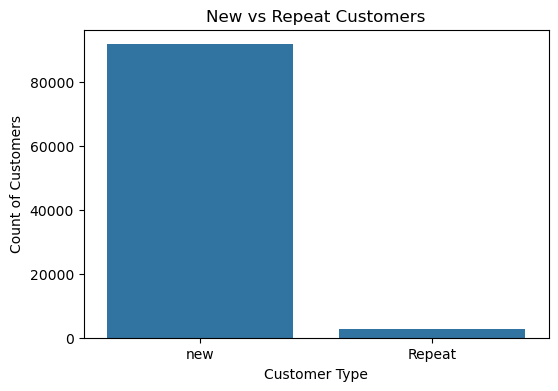

In [59]:
# New vs Repeated customers
customer_type_df = customer_360_df.copy()

customer_type_df["customer_type"] = customer_type_df.apply(lambda x: "new" if x["total_orders"] == 1 else "Repeat", axis = 1)

# print(customer_type_df.head(2))

customer_type_summary = customer_type_df["customer_type"].value_counts().reset_index()

print(customer_type_summary)

print(f"Plot new customer and repeated customers")

plt.figure(figsize=(6,4))
sns.countplot(data=customer_type_df, x="customer_type")
plt.title("New vs Repeat Customers")
plt.xlabel("Customer Type")
plt.ylabel("Count of Customers")
plt.show()



  value_segment  customer_count   avg_spend  total_revenue
0           Low           23683   43.884945     1039327.16
1        Medium           23679   86.160508     2040194.67
2          High           23679  151.407308     3585173.64
3     Very High           23680  571.082484    13523233.23
Plot between high value customers and low value customers
Revenue contribution by value segment


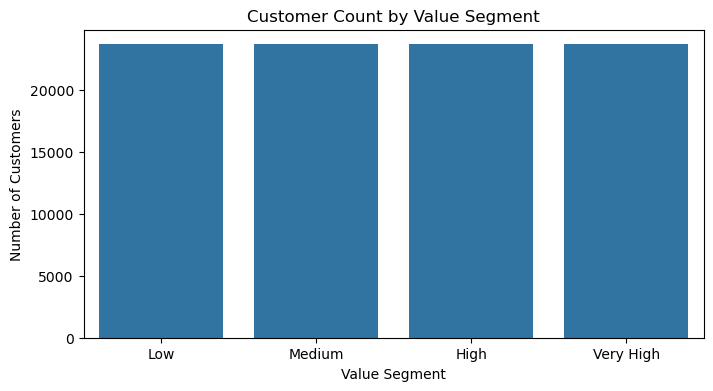

In [64]:
#High value vs Low value customers
# Here we can use qcut or cut. But will use qcut because donot want to add any strict boundary for our bucket.
# This process is usefull when you dont know what is the boundery, like here we dount know what is the boundery for Low labels.

customer_value_df = customer_360_df.copy()

customer_value_df["value_segment"] = pd.qcut(
    customer_value_df["total_spent"],
    q=4,
    labels = ["Low", "Medium", "High", "Very High"]
)

# value_summary = customer_value_df.groupby("value_segment",observed=True).agg(
#     customer_count = ("total_spent", "count"),
#     avg_spend = ("total_spent", "mean"),
#     total_revenue = ("total_spent", "sum")
# ).reset_index()

#Alternatively we can also do it in this way
value_summary = customer_value_df.groupby("value_segment",observed=True)["total_spent"].agg(
    customer_count="count",
    avg_spend="mean",
    total_revenue="sum"
).reset_index()

print(value_summary)


# Plot the graph between high value customers and low value customers
print(f"Plot between high value customers and low value customers")
print(f"Revenue contribution by value segment")

plt.figure(figsize=(8,4))
sns.barplot(data = value_summary, x = "value_segment", y = "customer_count")
plt.title("Customer Count by Value Segment")
plt.xlabel("Value Segment")
plt.ylabel("Number of Customers")
plt.show()




# Best way to decide which plot to choose.
•	If the x-axis is categorical then use bar chart. 
•	If you want to see which person shares how much value the use pie/donut chart .
•	If you want to compare two numeric measures, then use bar or scatter charst. 
•	If you want to see distribution shape, then use boxplot/ violin/ histogram. 


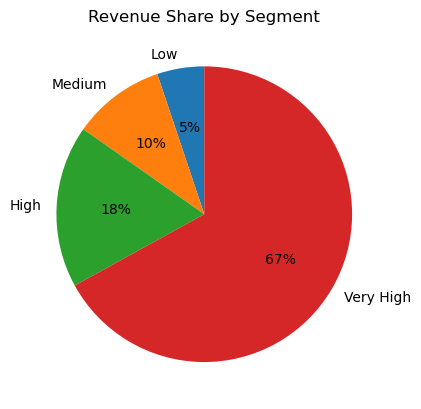

In [68]:
# From the above chart we can see each bucket have elqual number of customers, lets see which segment contributes hiow much to total revenue.

plt.pie(value_summary["total_revenue"], labels= value_summary["value_segment"], autopct= '%.0f%%', startangle = 90)
plt.title("Revenue Share by Segment")
plt.show()

In [86]:
# Geographic distribution of customers
customer_count_state = (
    final_df.groupby("customer_state")["customer_unique_id"]
    .nunique()
    .reset_index()
)

customer_count_state.columns = ["customer_state", "customer_count"]
customer_count_state.head()

,customer_state,customer_count
0,AC,77
1,AL,396
2,AM,140
3,AP,66
4,BA,3220


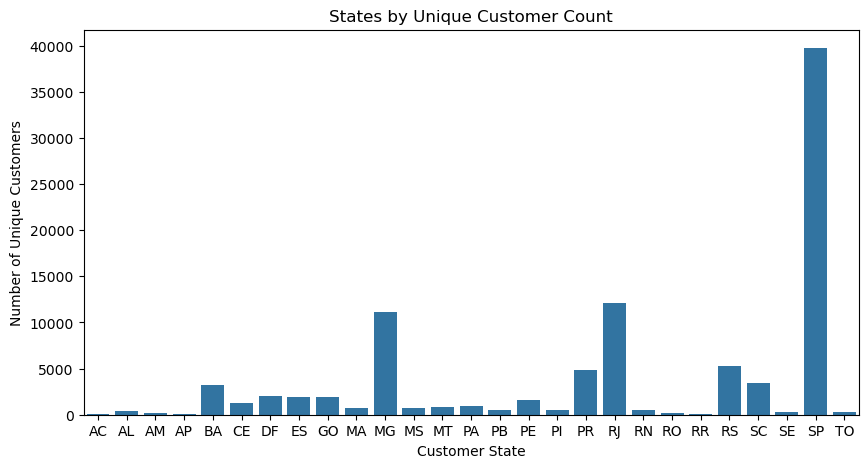

In [91]:
plt.figure(figsize=(10,5))
sns.barplot(data=customer_count_state, x = "customer_state", y = "customer_count")
plt.title("States by Unique Customer Count")
plt.xlabel("Customer State")
plt.ylabel("Number of Unique Customers")
plt.show()

In [89]:
# Revenue by state
customer_360_df.columns

Index(['customer_unique_id', 'total_orders', 'total_spent', 'avg_order_value', 'avg_approval_days', 'carrier_rate', 'avg_review_score', 'review_rate', 'total_order_value', 'avg_items_per_order', 'customer_lifetime_value', 'first_order_date', 'last_order_date', 'tenure_days', 'avg_delivery_days', 'avg_delivery_days_missing', 'delivered_orders', 'canceled_orders', 'purchase_frequency'], dtype='object')

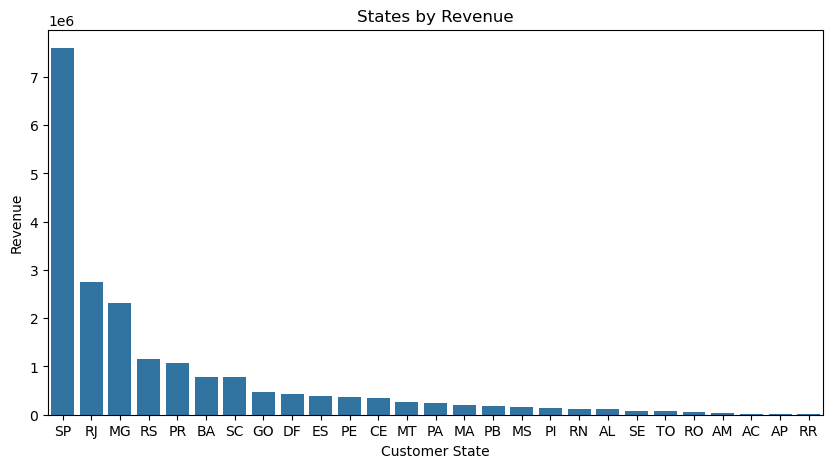

In [92]:
revenue_by_state = (
    final_df.groupby("customer_state")["payment_value"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

revenue_by_state

plt.figure(figsize=(10,5))
sns.barplot(data=revenue_by_state, x="customer_state", y = "payment_value")

plt.title("States by Revenue")
plt.xlabel("Customer State")
plt.ylabel("Revenue")
plt.show()


Index(['order_purchase_timestamp', 'payment_value'], dtype='object')
   order_purchase_timestamp  payment_value
0                   2016-09         347.52
1                   2016-10       72871.74
2                   2016-12          19.62
3                   2017-01      188107.24
4                   2017-02      344822.39
5                   2017-03      521299.33
6                   2017-04      501333.64
7                   2017-05      724696.48
8                   2017-06      602247.64
9                   2017-07      735468.88
10                  2017-08      825555.66
11                  2017-09     1017433.53
12                  2017-10     1023832.03
13                  2017-11     1579407.32
14                  2017-12     1031286.23
15                  2018-01     1403107.09
16                  2018-02     1305633.51
17                  2018-03     1468770.91
18                  2018-04     1487962.23
19                  2018-05     1497302.45
20                  2018-06 

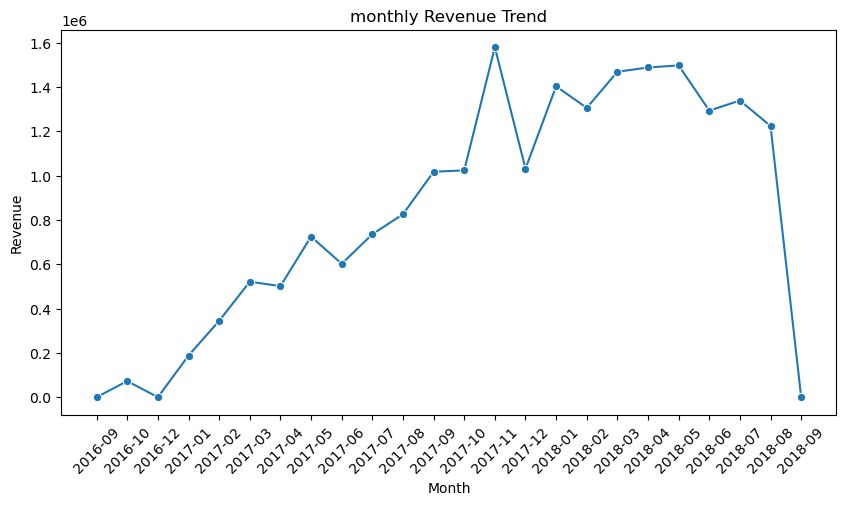

In [123]:
# Monthly revenue trends
# Monthly revenue calculation
# print(final_df["order_purchase_timestamp"].dt.to_period("M"))
monthly_revenue = final_df.groupby(final_df["order_purchase_timestamp"].dt.to_period("M"))["payment_value"].sum().reset_index()
print(monthly_revenue.columns)
monthly_revenue["order_purchase_timestamp"].dtype
monthly_revenue["order_purchase_timestamp"] = monthly_revenue["order_purchase_timestamp"].astype(str)
print(monthly_revenue)

# lets plot the trend
plt.figure(figsize=(10,5))
sns.lineplot(data=monthly_revenue, x = "order_purchase_timestamp", y = "payment_value", marker="o")
plt.xticks(rotation=45)
plt.title("monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.show()



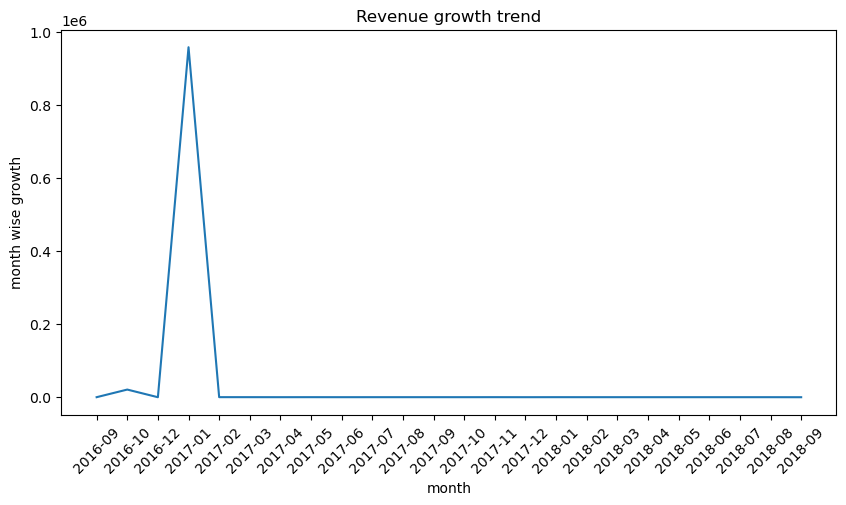

In [127]:
# Lets find how much revenue increased/decreased compared to previous month
# monthly_revenue = monthly_revenue.drop(columns=["mom_growth_pct"])
monthly_revenue["mon_growth_pct"] = monthly_revenue["payment_value"].pct_change() * 100

monthly_revenue["mon_growth_pct"] = monthly_revenue["mon_growth_pct"].fillna(0)

monthly_revenue

plt.figure(figsize=(10,5))
sns.lineplot(data = monthly_revenue, x = "order_purchase_timestamp", y = "mon_growth_pct")
plt.title("Revenue growth trend")
plt.xlabel("month")
plt.ylabel("month wise growth")
plt.xticks(rotation = 45 )
plt.show()

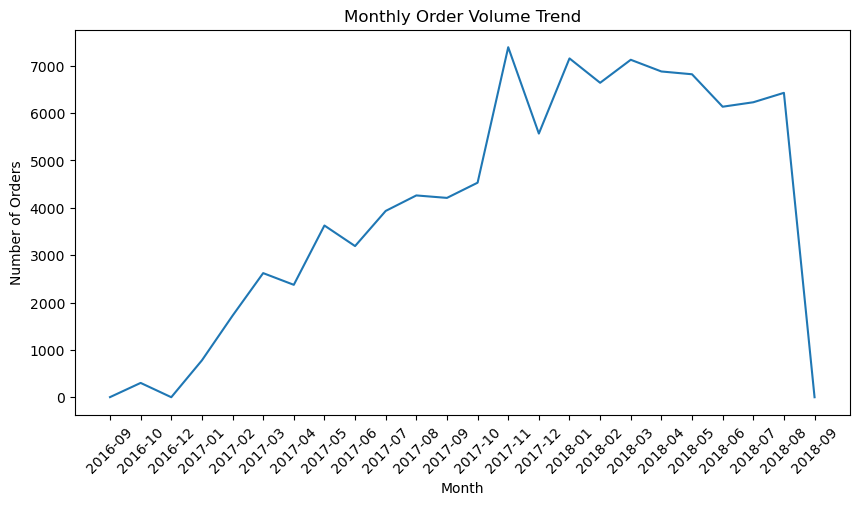

In [136]:
# Order Volume trend 

order_volumn_by_month = final_df.groupby(final_df["order_purchase_timestamp"].dt.to_period("M"))["order_id"].agg(total_orders_done = "nunique").reset_index()

order_volumn_by_month["order_purchase_timestamp"] = order_volumn_by_month["order_purchase_timestamp"].astype(str)

order_volumn_by_month["order_purchase_timestamp"].dtype

plt.figure(figsize=(10,5))
sns.lineplot(
    data = order_volumn_by_month,
    x = "order_purchase_timestamp",
    y = "total_orders_done",
    markers = "o"
)
plt.xticks(rotation = 45)
plt.title("Monthly Order Volume Trend")
plt.xlabel("Month")
plt.ylabel("Number of Orders")
plt.show()


In [11]:
final_df.columns

Index(['Unnamed: 0', 'order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date', 'customer_unique_id', 'customer_zip_code_prefix', 'customer_city', 'customer_state', 'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date', 'price', 'freight_value', 'seller_zip_code_prefix', 'seller_city', 'seller_state', 'product_category_name', 'product_name_lenght', 'product_description_lenght', 'product_photos_qty', 'product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm', 'product_category_name_english', 'payment_sequential', 'payment_type', 'payment_installments', 'payment_value', 'geolocation_zip_code_prefix', 'geolocation_city', 'geolocation_state', 'review_id', 'review_score', 'review_comment_title', 'review_comment_message', 'review_creation_date', 'review_answer_timestamp', 'order_has_approval', 'order_approved_in_days',
       'or

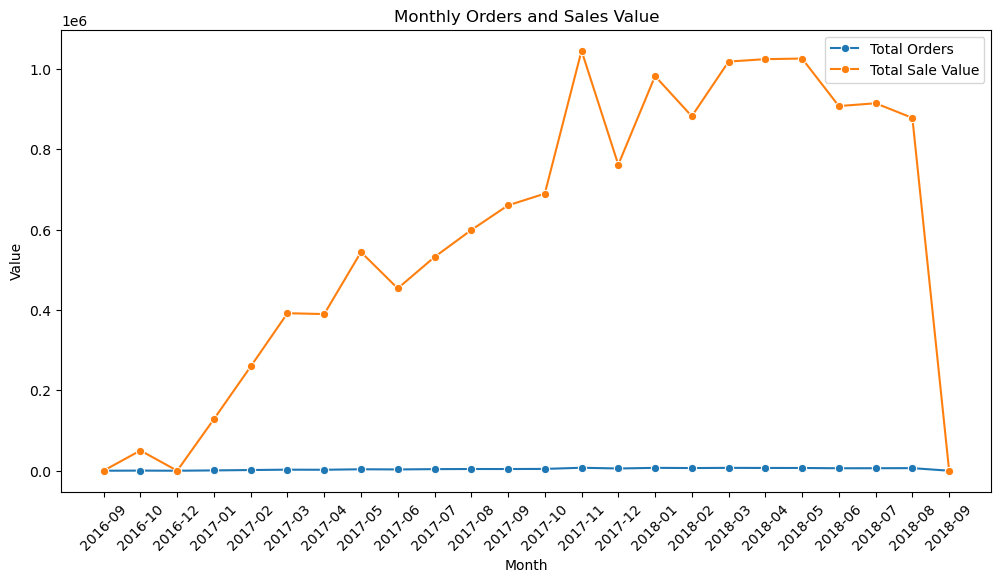

In [16]:
#peak sales period, order wise.

# final_df = pd.read_csv("final_df.csv")

# final_df["order_purchase_timestamp"] = final_df["order_purchase_timestamp"].apply(pd.to_datetime)

month_wise_sale = (final_df.groupby(final_df["order_purchase_timestamp"].dt.to_period("M"))["order_id"].agg(
    total_orders_done = "nunique",
).reset_index().sort_values("order_purchase_timestamp"))

month_wise_item_sold_value = (final_df.groupby(final_df["order_purchase_timestamp"].dt.to_period("M"))["price"].agg(
    total_sale_value = "sum"
).reset_index().sort_values("order_purchase_timestamp"))




merged = month_wise_sale.merge(
    month_wise_item_sold_value,
    on="order_purchase_timestamp"
)

merged["order_purchase_timestamp"] = merged["order_purchase_timestamp"].astype(str)

plt.figure(figsize=(12, 6))
sns.lineplot(data=merged, x="order_purchase_timestamp", y="total_orders_done", marker="o", label="Total Orders")
sns.lineplot(data=merged, x="order_purchase_timestamp", y="total_sale_value", marker="o", label="Total Sale Value")
plt.xticks(rotation=45)
plt.title("Monthly Orders and Sales Value")
plt.xlabel("Month")
plt.ylabel("Value")
plt.legend()
plt.show()



In [ ]:
# As the Orders are on thousands and sum of price is in scale of millions. The orders line is getting flat.
# So lets plot both of them together but with different y axis.

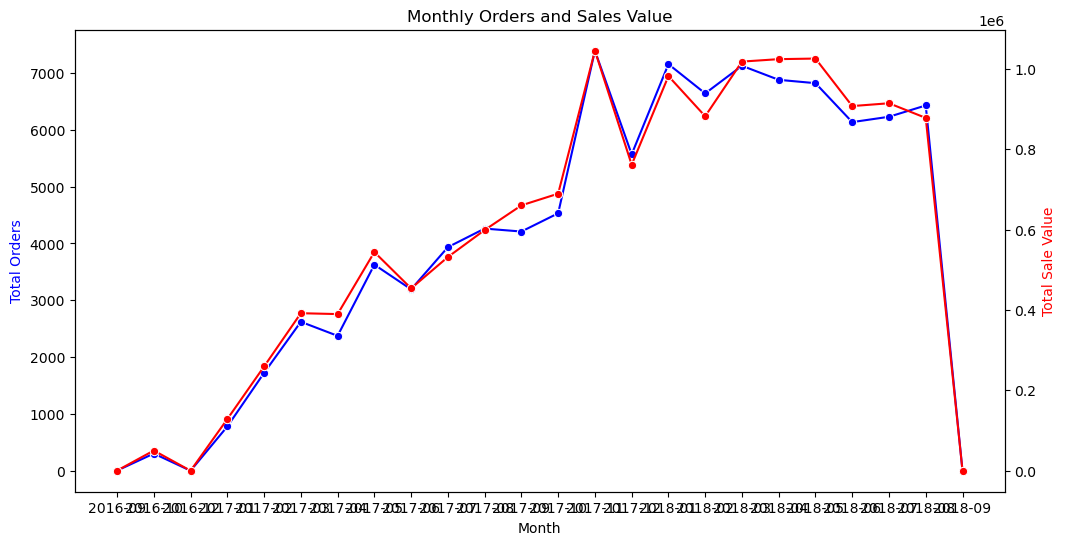

In [ ]:

fig, ax1 = plt.subplots(figsize=(12, 6)) # first y axis 

sns.lineplot(data=merged, x="order_purchase_timestamp", y="total_orders_done", marker="o", ax=ax1, color="blue")
ax1.set_ylabel("Total Orders", color="blue")

ax2 = ax1.twinx() # second y axis but with same x axis.
sns.lineplot(data=merged, x="order_purchase_timestamp", y="total_sale_value", marker="o", ax=ax2, color="red")
ax2.set_ylabel("Total Sale Value", color="red")

ax1.set_title("Monthly Orders and Sales Value")
ax1.set_xlabel("Month")
plt.xticks(rotation=45)
plt.show()


In [ ]:
# from the above code we can see both other and total sale moves along so maximum order month will also give us the max sale.
# Peak sales periods 

peak_sales_periods = month_wise_sale.loc[month_wise_sale["total_orders_done"] == month_wise_sale["total_orders_done"].max()]

peak_sales_periods

# From the monthly orders and sales value chart, both order volume and sales value peak in the same month, 
# indicating that the period with the highest order activity also generated the highest sales value.

,order_purchase_timestamp,total_orders_done
13,2017-11,7390


In [38]:
final_df.head(3)
final_df.loc[final_df["product_id"] == "a1804276d9941ac0733cfd409f5206eb"]

,Unnamed: 0,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,seller_zip_code_prefix,seller_city,seller_state,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_category_name_english,payment_sequential,payment_type,payment_installments,payment_value,geolocation_zip_code_prefix,geolocation_city,geolocation_state,review_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp,order_has_approval,order_approved_in_days,order_handed_to_carrier,order_shipped_in_days,cat_missing_flag,english_cat_missing_flag,delivery_days,geo_missing_flag,has_review_comment
8,8,136cce7faa42fdb2cefd53fdc79a6098,ed0271e0b7da060a393796590e7b737a,invoiced,2017-04-11 12:22:08,2017-04-13 13:25:17,NaN,NaN,2017-05-09,36edbb3fb164b1f16485364b6fb04c73,98900,santa rosa,RS,1,a1804276d9941ac0733cfd409f5206eb,dc8798cbf453b7e0f98745e396cc5616,2017-04-19 13:25:17,49.9,16.05,5455,sao paulo,SP,NaN,0.0,0.0,0.0,600.0,35.0,35.0,15.0,NaN,1.0,credit_card,1.0,65.95,98900.0,santa rosa,RS,e07549ef5311abcc92ba1784b093fb56,2,NaN,fiquei triste por n ter me atendido.,2017-05-13,2017-05-13 20:25:42,1,2.04,0,NaN,0,0,NaN,0,1
58160,58160,9c9504bb506aa1635fb6ad19be9bcfa9,5638c42751e237d265ad0c0536256311,delivered,2017-09-06 00:33:14,2017-09-08 07:03:44,2017-09-13 19:52:19,2017-09-14 16:58:54,2017-09-19,f7e0fe56fc317ded1c63a772a48d0159,6112,osasco,SP,1,a1804276d9941ac0733cfd409f5206eb,dc8798cbf453b7e0f98745e396cc5616,2017-09-14 07:03:44,49.9,7.78,5455,sao paulo,SP,NaN,0.0,0.0,0.0,600.0,35.0,35.0,15.0,NaN,1.0,credit_card,1.0,57.68,6112.0,osasco,SP,42dbe41e73179a583776776f7146005a,1,NaN,O produto veio errado eu pedi no tamanho 44 e veio no tamanho 40.tem 3 dia que tô querendo tentar a troca beijos nada da loja me responder...,2017-09-15 00:00:00,2017-09-19 00:35:24,1,2.27,1,0.88,0,0,8.0,0,1


,product_category_name,number_of_orders,rank,value_segment
13,cama_mesa_banho,9313,1,top
11,beleza_saude,8771,2,top
32,esporte_lazer,7669,3,top
44,informatica_acessorios,6649,4,top
54,moveis_decoracao,6398,5,top
...,...,...,...,...
17,cds_dvds_musicais,12,66,low
46,la_cuisine,12,66,low
37,fashion_roupa_infanto_juvenil,8,67,low
60,pc_gamer,8,67,low


In [ ]:
# •	Top-selling product categories 

number_of_orders_by_cat = final_df.groupby(final_df["product_category_name"].fillna("unknown"))["order_id"].agg(number_of_orders = "nunique").reset_index()

number_of_orders_by_cat["rank"] = number_of_orders_by_cat["number_of_orders"].rank(method = "dense", ascending= False).astype(int)

#lets create bucket as top, average, low

number_of_orders_by_cat["value_segment"] = pd.qcut(
    number_of_orders_by_cat["number_of_orders"],
    q= 3,
    labels=["low", "average", "top"]
)

number_of_orders_by_cat.sort_values("rank", ascending=True)

number_of_orders_by_cat[number_of_orders_by_cat["value_segment"] == "top"]



,product_category_name,number_of_orders,rank,value_segment
8,automotivo,3877,9,top
9,bebes,2861,14,top
11,beleza_saude,8771,2,top
12,brinquedos,3853,10,top
13,cama_mesa_banho,9313,1,top
20,consoles_games,1052,21,top
21,construcao_ferramentas_construcao,743,24,top
26,cool_stuff,3599,11,top
28,eletrodomesticos,761,23,top
30,eletronicos,2531,15,top


In [59]:
final_df.columns

Index(['Unnamed: 0', 'order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date', 'customer_unique_id', 'customer_zip_code_prefix', 'customer_city', 'customer_state', 'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date', 'price', 'freight_value', 'seller_zip_code_prefix', 'seller_city', 'seller_state', 'product_category_name', 'product_name_lenght', 'product_description_lenght', 'product_photos_qty', 'product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm', 'product_category_name_english', 'payment_sequential', 'payment_type', 'payment_installments', 'payment_value', 'geolocation_zip_code_prefix', 'geolocation_city', 'geolocation_state', 'review_id', 'review_score', 'review_comment_title', 'review_comment_message', 'review_creation_date', 'review_answer_timestamp', 'order_has_approval', 'order_approved_in_days',
       'or

        product_category_name  total_revenue
0   agro_industria_e_comercio      118730.61
1                   alimentos       44155.32
2           alimentos_bebidas       27438.47
3                       artes       30791.38
4          artes_e_artesanato        2326.17
..                        ...            ...
69   tablets_impressao_imagem        8985.35
70                  telefonia      482796.72
71             telefonia_fixa      206404.01
72                    unknown      251886.12
73      utilidades_domesticas     1091709.15

[74 rows x 2 columns]


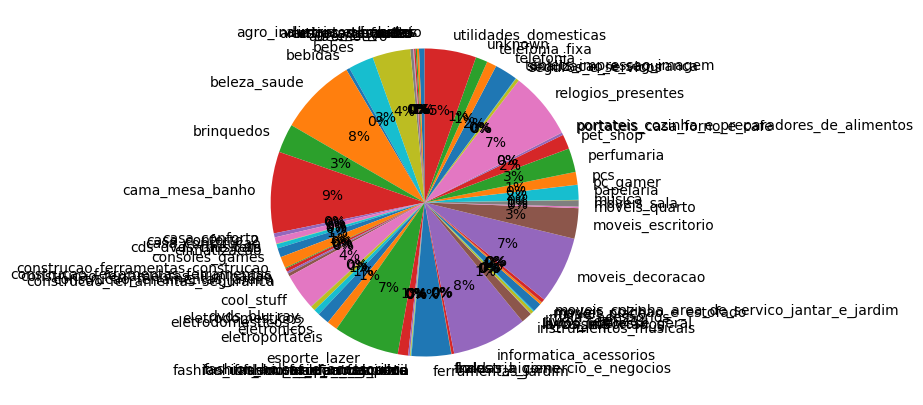

In [62]:
# •	Revenue contribution by category 
rev_contribution_by_cat = final_df.groupby(final_df["product_category_name"].fillna("unknown"))["payment_value"].agg(total_revenue = "sum").reset_index()
print(rev_contribution_by_cat)
plt.figure(figsize=(12, 5))
plt.pie(rev_contribution_by_cat["total_revenue"], labels= rev_contribution_by_cat["product_category_name"], autopct= '%.0f%%', startangle = 90 )
plt.show()

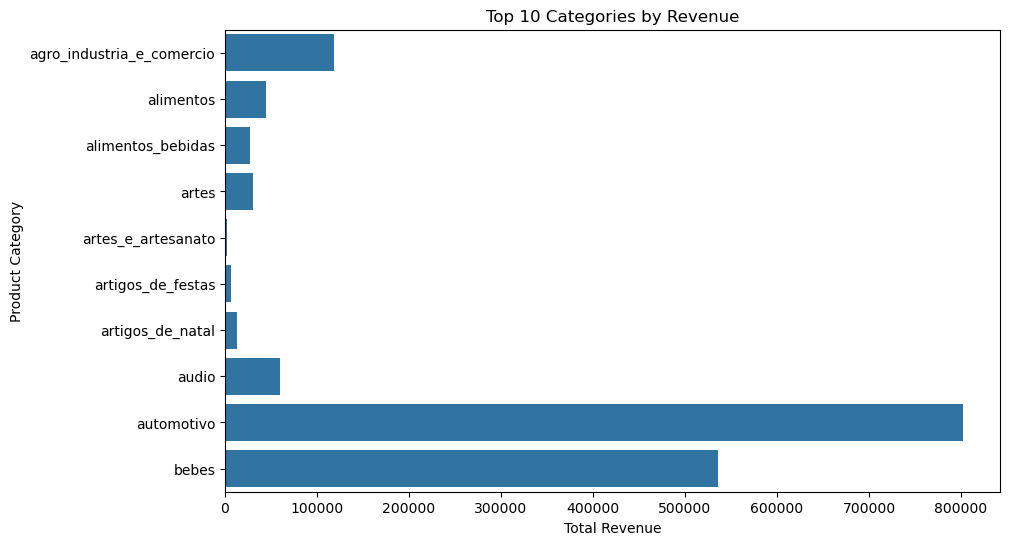

In [65]:

plt.figure(figsize=(10, 6))
sns.barplot(data=rev_contribution_by_cat.head(10), y="product_category_name", x="total_revenue")
plt.title("Top 10 Categories by Revenue")
plt.xlabel("Total Revenue")
plt.ylabel("Product Category")
plt.show()


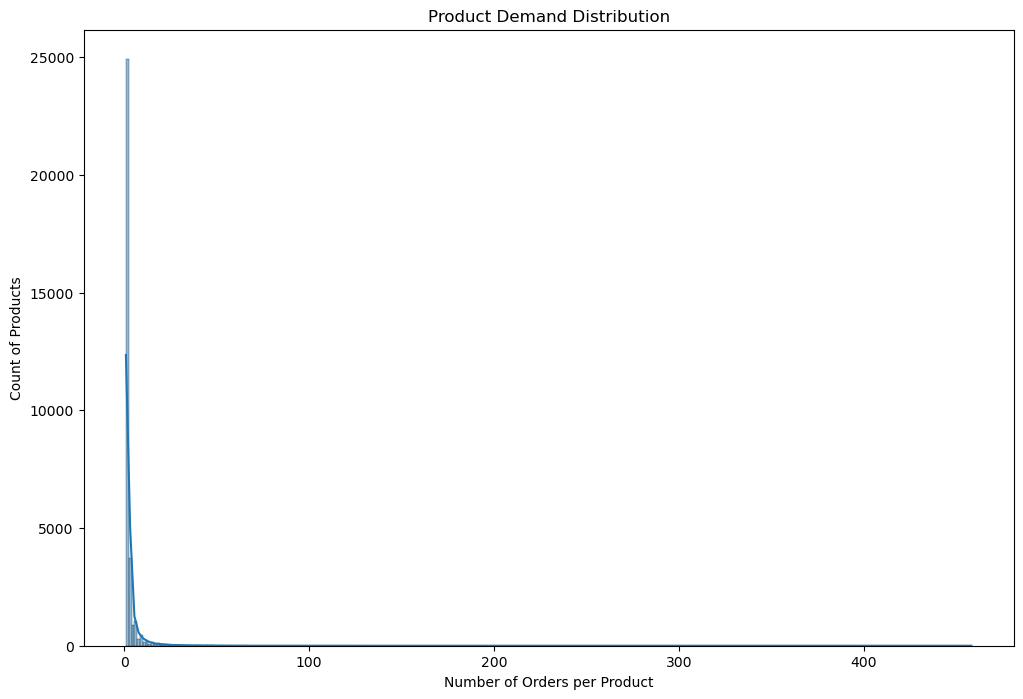

In [79]:
# •	Product demand distribution 
product_demand_df = final_df.groupby("product_id")["order_id"].agg(number_of_orders = "nunique").reset_index()
plt.figure(figsize=(12,8))
sns.histplot(product_demand_df["number_of_orders"], bins= 300,kde=True)
plt.title("Product Demand Distribution")
plt.xlabel("Number of Orders per Product")
plt.ylabel("Count of Products")
# plt.xscale("log")
plt.show()


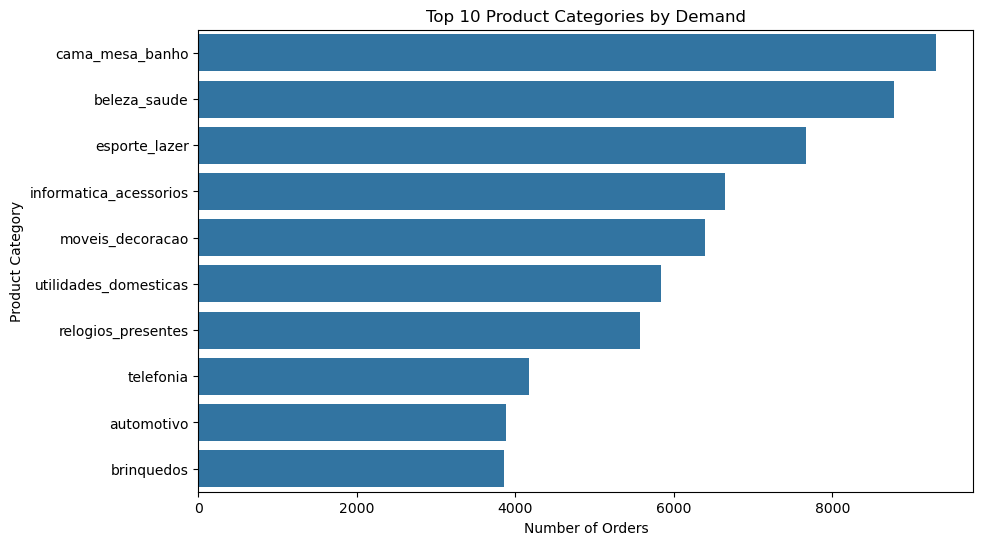

In [70]:
category_demand_df = (
    final_df.groupby(final_df["product_category_name"].fillna("unknown"))["order_id"]
    .nunique()
    .reset_index(name="number_of_orders")
    .sort_values("number_of_orders", ascending=False)
)

plt.figure(figsize=(10, 6))
sns.barplot(data=category_demand_df.head(10), y="product_category_name", x="number_of_orders")
plt.title("Top 10 Product Categories by Demand")
plt.xlabel("Number of Orders")
plt.ylabel("Product Category")
plt.show()

In [82]:
# •	Top-performing sellers 
# We will find top performing products and then we will find which are the sellers for those items.
final_df.columns

number_of_orders_per_product = (final_df.groupby("product_id")["order_id"].agg(order_count_per_product="nunique").reset_index())

top_selling_product = pd.qcut(number_of_orders_per_product["order_count_per_product"], q=3, labels=["low", "average", "top"])

top_selling_product


ValueError: Bin edges must be unique: Index([1.0, 1.0, 2.0, 458.0], dtype='float64', name='order_count_per_product').
You can drop duplicate edges by setting the 'duplicates' kwarg

In [ ]:
# •	Seller contribution to revenue 


In [ ]:
# •	Seller distribution 